In [ ]:
#modules/libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
#Reads netflix_titles.csv
curr_csv = pd.read_csv("netflix_titles.csv")
curr_csv.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#Divides by the missing/present sum values by the total number of rows
print(((curr_csv.isnull().sum()/curr_csv.shape[0])*100).round(2))

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


In [7]:
#fills in the unknowns with 'unknow'
curr_csv['director'] = curr_csv['director'].fillna('unknow')
curr_csv['cast'] = curr_csv['cast'].fillna('unknow')
curr_csv['country'] = curr_csv['country'].fillna('unknow')
curr_csv['date_added'] = curr_csv['date_added'].fillna('unknow')
curr_csv['rating'] = curr_csv['rating'].fillna('unknow')
curr_csv['duration'] = curr_csv['duration'].fillna('unknow')

In [8]:
print(((curr_csv.isnull().sum()/curr_csv.shape[0])*100).round(2))

show_id         0.0
type            0.0
title           0.0
director        0.0
cast            0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
description     0.0
dtype: float64


country
United States     938
unknow            391
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Name: count, dtype: int64


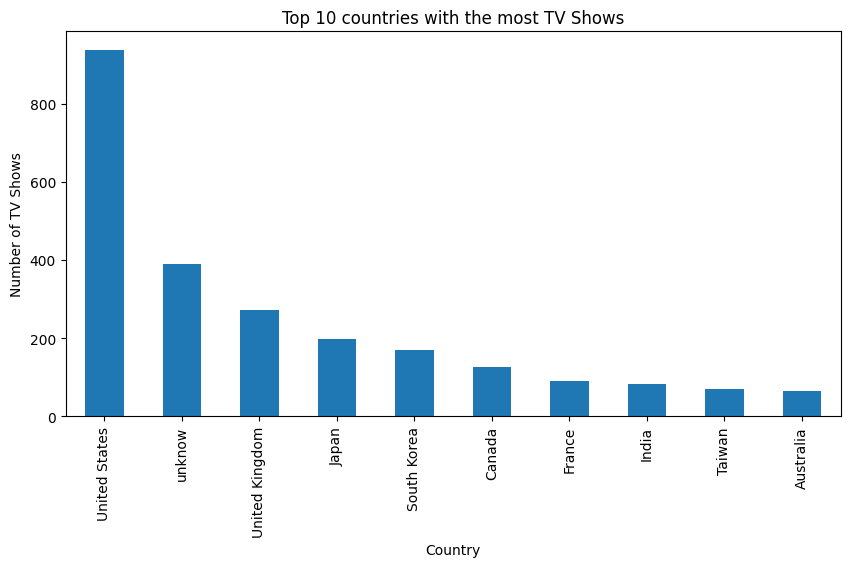

In [12]:
countries = curr_csv[curr_csv['type'] == "TV Show"]["country"].dropna().str.split(", ").explode()  
#picks tv shows from the country column, dropna() removes empty row values, str.split() splits into a list and uses ',' as a seperator, explode() turns each element into its own row
top_countries = countries.value_counts().head(10) #value_counts() counts how many time each country appears, from frequent -> least. head(10) picks top 10
print(top_countries)

    #Creating a bar graph
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 countries with the most TV Shows')
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')
plt.show()

country
United States     2751
India              962
United Kingdom     532
unknow             440
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Name: count, dtype: int64


Text(0, 0.5, 'Number of Movies')

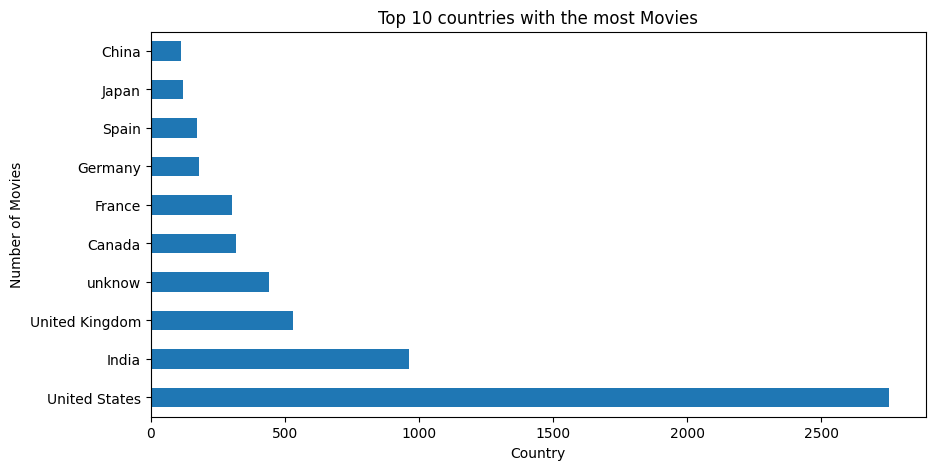

In [13]:
countries = curr_csv[curr_csv["type"]=="Movie"]["country"].dropna().str.split(", ").explode()
top_countries = countries.value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="barh")
plt.title("Top 10 countries with the most Movies")
plt.xlabel("Country")
plt.ylabel("Number of Movies")


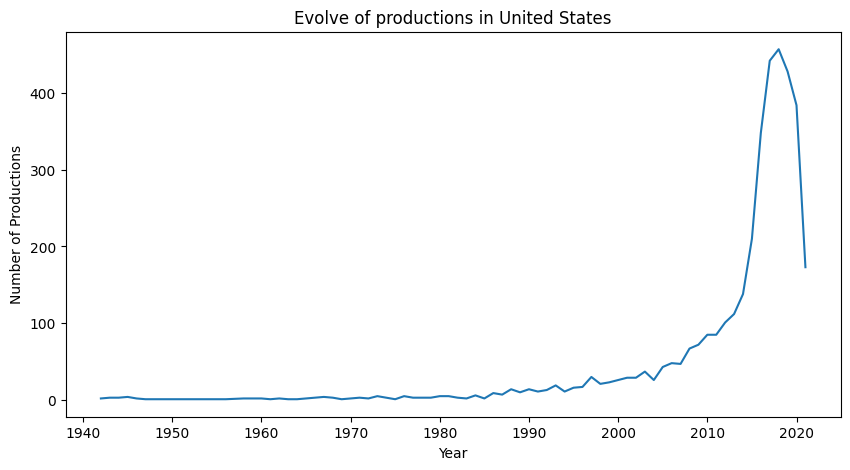

In [16]:
def get_production_by_country(country): 
    return curr_csv[curr_csv["country"].str.contains(country, na=False)]['release_year'].value_counts().sort_index()
name = "United States"
production = get_production_by_country(name)
plt.figure(figsize=(10, 5))
production.plot()
plt.title(f'Evolve of productions in {name}')
plt.xlabel("Year")
plt.ylabel("Number of Productions")
plt.show()